In [70]:
import pandas as pd
import statsmodels as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse

In [71]:
df = pd.read_csv("ngshistory.csv")
df.isna().sum()

Unnamed: 0              0
Week ending             0
Source                  0
East Region             0
Midwest Region          0
Mountain Region         0
Pacific Region          0
South Central Region    0
Salt                    0
NonSalt                 0
Total Lower 48          0
dtype: int64

In [93]:
def plot_model(x, y, pred, model_name:str, rmse:int, order:tuple, seasonal_order:list, exog:list=None):
    resid = y - pred
    plt.figure(figsize=(12, 4))
    plt.plot(x, y, color='black', label='actual', linewidth=1.5, alpha=0.7, zorder=1)
    plt.plot(x, pred, color='#4682B4', label='predicted', linewidth=2, zorder=3)
    plt.plot(x, resid, color='#ff7f0e', alpha=0.7, linewidth=1, label='resid')
    plt.xlabel('In Weeks')
    plt.ylabel('billion cubic ft')
    plt.legend()
    plt.grid()
    plt.title("Predicted Natural Gas Storage Volume")
    plt.suptitle(f"{model_name}, O:{order}, S:{seasonal_order}, rmse:{rmse:.2f}")
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.savefig(f"{model_name}_{order}_S{seasonal_order}.png")
    plt.show()

In [73]:
from log_model import log_model

In [74]:
df.columns

Index(['Unnamed: 0', 'Week ending', 'Source', 'East Region', 'Midwest Region',
       'Mountain Region', 'Pacific Region', 'South Central Region', 'Salt',
       'NonSalt', 'Total Lower 48'],
      dtype='str')

In [75]:
label = df['Total Lower 48']

In [76]:
year_mean = label.rolling(window=52).mean()
df_diff = label.diff()

In [77]:
df['Week ending'] = pd.to_datetime(df['Week ending'])

In [78]:
df_diff_52 = label.diff(52)

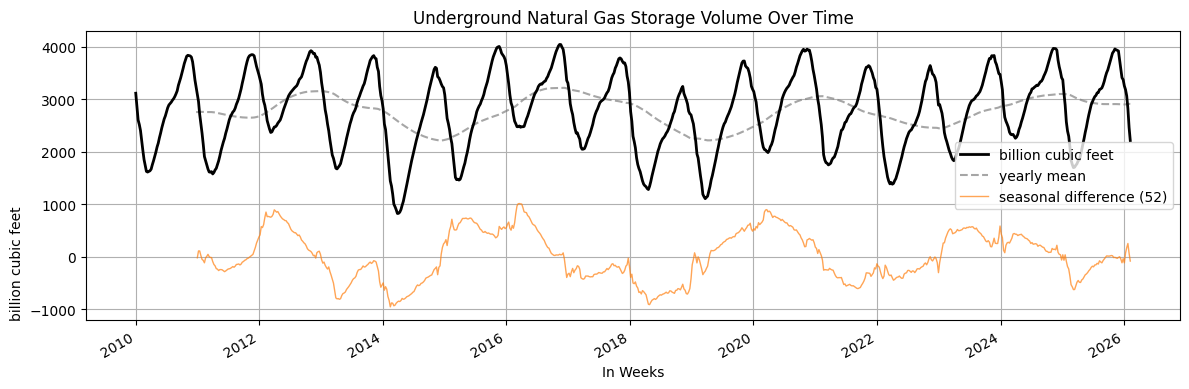

In [87]:
plt.figure(figsize=(12, 4))
plt.plot(df['Week ending'], label, label='billion cubic feet',color='black', linewidth=2, zorder=3)
plt.plot(df['Week ending'], year_mean, label='yearly mean', color='gray', linestyle='--', alpha=0.7, linewidth=1.5)
plt.plot(df["Week ending"], df_diff_52, label='seasonal difference (52)', color='#ff7f0e', alpha=0.7, linewidth=1)
plt.xlabel('In Weeks')
plt.ylabel('billion cubic feet', loc="bottom")
plt.legend()
plt.grid()
plt.title('Underground Natural Gas Storage Volume Over Time')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.tight_layout()
#plt.savefig("plots/data_exp.png")
plt.show()

In [80]:
autocorr_lst = [label.autocorr(i) for i in range(30)]
autocorr_lst.index(min(autocorr_lst))

27

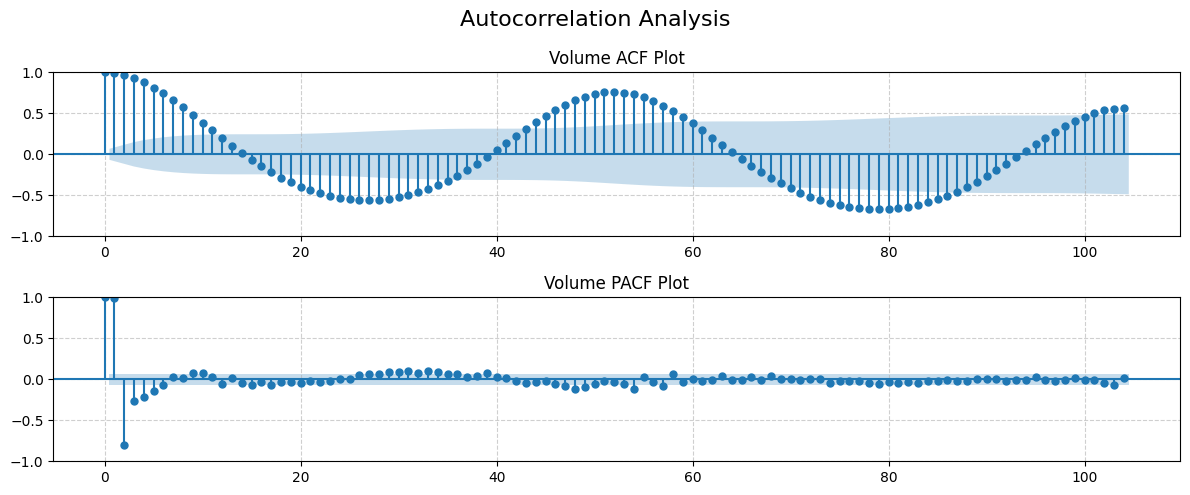

In [81]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

plot_acf(label, ax=ax1, title='Volume ACF Plot', lags=104)
plot_pacf(label, ax=ax2, title='Volume PACF Plot', lags=104)

ax1.grid(True, linestyle='--', alpha=0.6)
ax2.grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Autocorrelation Analysis', fontsize=16)

plt.tight_layout()
plt.savefig("autocorr.png")
plt.show()

In [82]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(label, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -7.3815762385537305
p-value: 8.445370937524531e-11


In [84]:
order=(5, 0, 5)
seasonal_order = (2, 1, 2, 52)
model2 = SARIMAX(label[:-104], order=order, seasonal_order=seasonal_order)
result2 = model2.fit()
result2.summary()

/Users/cyqmain/.work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                          Total Lower 48   No. Observations:                  737
Model:             SARIMAX(5, 0, 5)x(2, 1, [1, 2], 52)   Log Likelihood               -3609.873
Date:                                 Wed, 15 Apr 2026   AIC                           7249.746
Time:                                         20:15:46   BIC                           7317.687
Sample:                                              0   HQIC                          7276.035
                                                 - 737                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8682      0.057    -15.139      0.000      -0.981      -0.756
ar.L2          1.8044      0.076     23.747      0.000       1.655       1.953
ar.L3          1.8427      0.057     32.475      0.000       1.732       1.954
ar.L4         -0.8051      0.074    -10.860      0.000      -0.950      -0.660
ar.L5         -0.9739      0.045    -21.430      0.000      -1.063      -0.885
ma.L1          2.1741      0.101     21.434      0.000       1.975       2.373
ma.L2          0.6097      0.302      2.016      0.044       0.017       1.202
ma.L3         -1.8413      0.365     -5.044      0.000      -2.557      -1.126
ma.L4         -1.6091      0.215     -7.471      0.000      -2.031      -1.187
ma.L5         -0.3334      0.055     -6.042      0.000      -0.442      -0.225
ar.S.L52       0.8109      0.225      3.605      0.000       0.370       1.252
ar.S.L104      0.0060      0.050      0.120      0.904      -0.091       0.103
ma.S.L52      -1.6147      0.221     -7.295      0.000      -2.049      -1.181
ma.S.L104      0.6533      0.175      3.736      0.000       0.311       0.996
sigma2      2254.9284    174.060     12.955      0.000    1913.777    2596.079
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):              1660.98
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               0.75   Skew:                            -0.93
Prob(H) (two-sided):                  0.03   Kurtosis:                        10.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
df_pred2 = result2.predict(start=len(label) - 104, end=len(label) - 1)
loss2 = rmse(df_pred2, label[-104:])
loss2

np.float64(157.09705830298063)

In [ ]:
"""log_model("log/model_log.jsonl", "SARIMA", result2.aic, result2.bic, loss2, param_names=result2.params.index.to_list()\
          , param_vals=result2.params.to_list())"""

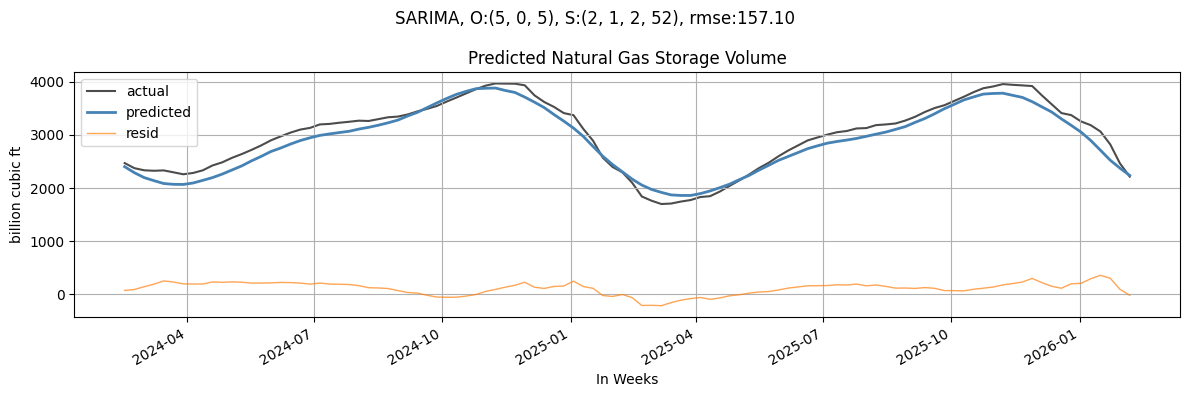

In [94]:
plot_model(df['Week ending'][-104:], label[-104:], df_pred2, "SARIMA", loss2,\
           order=order, seasonal_order=seasonal_order)

In [ ]:
y = df['Total Lower 48']

In [ ]:
acc = {}
strt = len(y) - 5 * 52
c = 0
for i in range(strt, len(y), 52):
    order=(2, 0, 5)
    seasonal_order = (2, 1, 2, 52)
    model2 = SARIMAX(y[:i], order=order, seasonal_order=seasonal_order)
    result2 = model2.fit()
    print(f"model bic: {result2.bic}")
    pred = result2.predict(start=i, end=i+52)
    actual = y[i:i+53]
    min_len = min(len(pred), len(actual))
    c+=1
    acc[f"Fold {c}"] = rmse(pred[:min_len], actual[:min_len])
log_model("log/model_log.jsonl", "SARIMA", result2.aic, result2.bic, rmse(pred[:min_len], actual[:min_len]), param_names=result2.params.index.to_list()\
        , param_vals=result2.params.to_list(), crossfold_acc=acc)